In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import kagglehub

# 1. Загрузка датасета
path =  "C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9"
print("Изначальный путь к датасету:", path)

# Умный поиск папки с классами
dataset_dir = path
while True:
    items = os.listdir(dataset_dir)
    dirs = [d for d in items if os.path.isdir(os.path.join(dataset_dir, d))]
    if len(dirs) == 1:
        dataset_dir = os.path.join(dataset_dir, dirs[0])
    else:
        break

print("Рабочая папка с датасетом:", dataset_dir)

IMG_SIZE = 32
MAX_IMAGES_PER_CLASS = 5000 

def load_and_preprocess_data(data_path, img_size, max_per_class):
    images = []
    labels = []
    class_names = []
    
    # Ищем папки с классами
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    classes.sort()
    
    for label, class_name in enumerate(classes):
        class_names.append(class_name)
        class_path = os.path.join(data_path, class_name)
        
        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break
                
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
            
            # Защита от битых файлов
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0 # Нормализация
                images.append(img)
                labels.append(label)
                count += 1
                
    return np.array(images), np.array(labels), class_names

# Загружаем данные
X, y, class_names = load_and_preprocess_data(dataset_dir, IMG_SIZE, MAX_IMAGES_PER_CLASS)

# Проверка, что данные загрузились
if len(X) == 0:
    raise ValueError(f"ОШИБКА: Изображения не найдены в папке {dataset_dir}. Проверьте структуру датасета.")

# Добавляем измерение канала (для ЧБ картинки это 1)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

NUM_CLASSES = len(class_names)
print(f"Количество найденных классов: {NUM_CLASSES}")
print(f"Формат загруженных данных: {X.shape}")

# Разделение на train и test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encoding
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(f"Размер тренировочных данных: {X_train.shape}")
print(f"Размер тестовых данных: {X_test.shape}")

# Функция для отрисовки графиков и лог-файл (словарь)
results_log = {}

def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

Изначальный путь к датасету: C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9
Рабочая папка с датасетом: C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9\CompleteImages\All data (Compressed)
Количество найденных классов: 16
Формат загруженных данных: (80000, 32, 32, 1)
Размер тренировочных данных: (64000, 32, 32, 1)
Размер тестовых данных: (16000, 32, 32, 1)


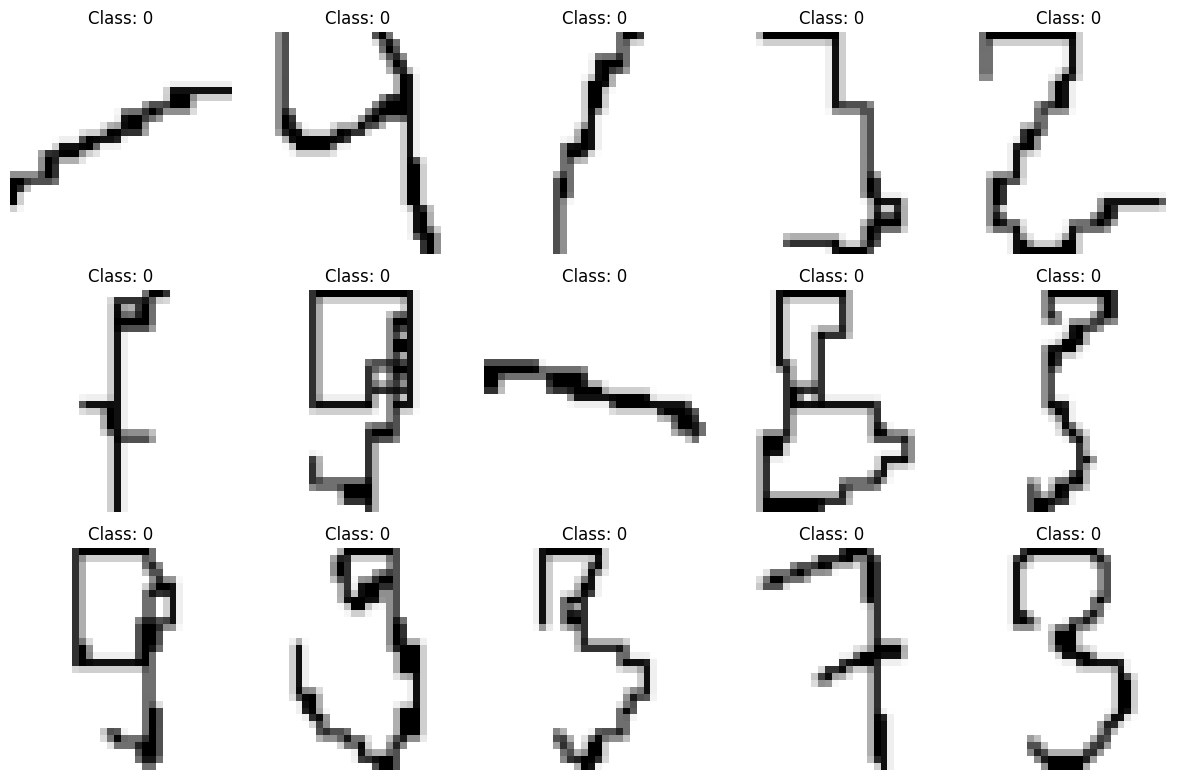

In [36]:
# Предпросмотр данных
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '*', '/', '[', ']']

plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    img = X_train[i].squeeze() 
    plt.imshow(img, cmap='gray')
    
    label_idx = np.argmax(y_train[i])
    title = class_names[label_idx] if label_idx < len(class_names) else str(label_idx)
    
    plt.title(f"Class: {title}")
    plt.axis('off')

plt.tight_layout()
plt.show()

c:\Users\Nikita\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,920 (1.21 MB)

 Trainable params: 315,920 (1.21 MB)

 Non-trainable params: 0 (0.00 B)


--- Обучение базовой модели ---
Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8786 - loss: 0.3879 - val_accuracy: 0.9454 - val_loss: 0.1678
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9629 - loss: 0.1141 - val_accuracy: 0.9637 - val_loss: 0.1111
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9729 - loss: 0.0784 - val_accuracy: 0.9680 - val_loss: 0.0980
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9771 - loss: 0.0637 - val_accuracy: 0.9769 - val_loss: 0.0693
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9802 - loss: 0.0534 - val_accuracy: 0.9766 - val_loss: 0.0685
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9826 - loss: 0.0465 - val_accuracy: 0.9746 - val_loss: 0.0745
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9845 - loss: 0.0411 - val_accuracy: 0.9785 - val_loss: 0.0655
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/

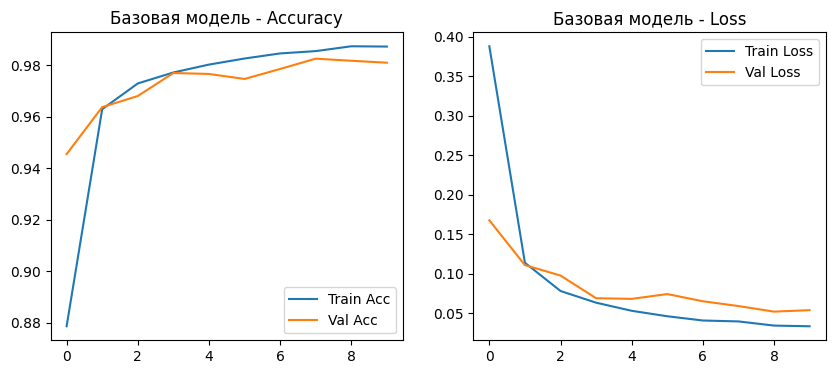

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Предсказанный класс стороннего изображения: %


In [3]:
# 1. Базовая модель
base_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

base_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 1.2 Вывод архитектуры
base_model.summary()

# Обучение
print("\n--- Обучение базовой модели ---")
history_base = base_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)

# Сохранение результатов
loss, acc = base_model.evaluate(X_test, y_test_cat, verbose=0)
results_log['Base Model'] = acc
plot_history(history_base, "Базовая модель")

# 1.4 Проверка
try:
    test_img = 'my_digit.png'
    img_ext = cv2.imread(test_img, cv2.IMREAD_GRAYSCALE)
    img_ext = cv2.resize(img_ext, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_ext = img_ext.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    pred = base_model.predict(img_ext)
    print(f"Предсказанный класс стороннего изображения: {class_names[np.argmax(pred)]}")
except:
    print(f"Сторонний файл {test_img} не найден. Для проверки загрузите файл.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,496 (2.40 MB)

 Trainable params: 628,496 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.9128 - loss: 0.2792 - val_accuracy: 0.9548 - val_loss: 0.1367
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9721 - loss: 0.0824 - val_accuracy: 0.9674 - val_loss: 0.0955
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9786 - loss: 0.0603 - val_accuracy: 0.9738 - val_loss: 0.0751
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9821 - loss: 0.0509 - val_accuracy: 0.9804 - val_loss: 0.0602
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9832 - loss: 0.0448 - val_accuracy: 0.9769 - val_loss: 0.0585
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9853 - loss: 0.0387 - val_accuracy: 0.9784 - val_loss: 0.0726
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9862 - loss: 0.0361 - val_accuracy: 0.9828 - val_loss: 0.0499
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9866 -

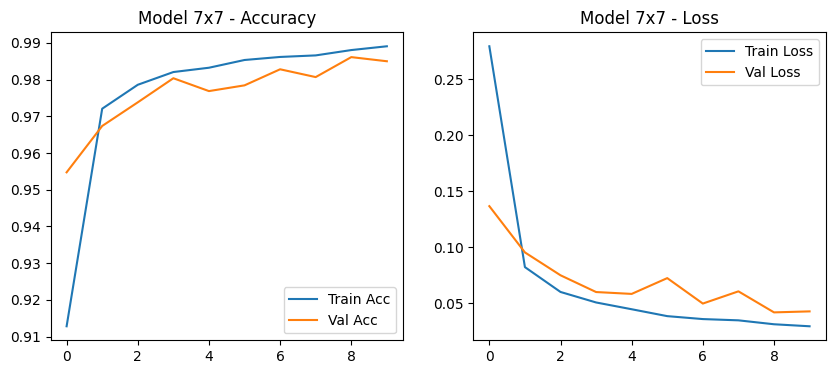

Точность Model 7x7: 0.9850


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,576 (2.21 MB)

 Trainable params: 578,576 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.9070 - loss: 0.2957 - val_accuracy: 0.9639 - val_loss: 0.1130
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9723 - loss: 0.0837 - val_accuracy: 0.9772 - val_loss: 0.0742
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9788 - loss: 0.0601 - val_accuracy: 0.9728 - val_loss: 0.0787
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9834 - loss: 0.0488 - val_accuracy: 0.9792 - val_loss: 0.0607
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9847 - loss: 0.0426 - val_accuracy: 0.9803 - val_loss: 0.0599
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9861 - loss: 0.0384 - val_accuracy: 0.9821 - val_loss: 0.0500
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9881 - loss: 0.0336 - val_accuracy: 0.9816 - val_loss: 0.0563
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9878 -

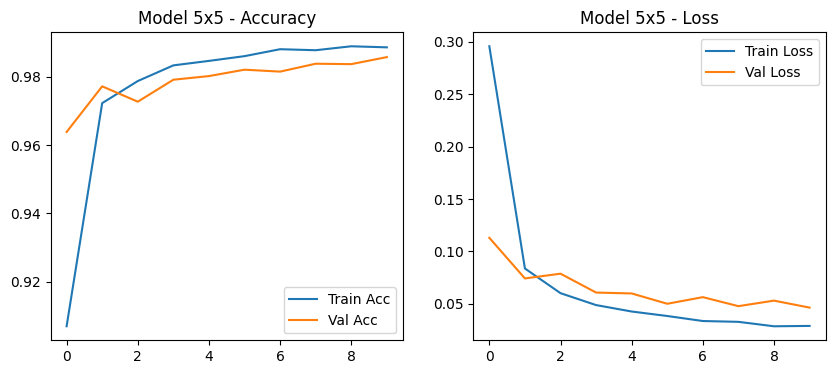

Точность Model 5x5: 0.9858


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,808 (2.08 MB)

 Trainable params: 545,808 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9082 - loss: 0.2960 - val_accuracy: 0.9667 - val_loss: 0.1039
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9729 - loss: 0.0825 - val_accuracy: 0.9768 - val_loss: 0.0736
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9791 - loss: 0.0591 - val_accuracy: 0.9803 - val_loss: 0.0583
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9836 - loss: 0.0471 - val_accuracy: 0.9820 - val_loss: 0.0548
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9844 - loss: 0.0407 - val_accuracy: 0.9816 - val_loss: 0.0541
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9876 - loss: 0.0348 - val_accuracy: 0.9839 - val_loss: 0.0493
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9879 - loss: 0.0324 - val_accuracy: 0.9864 - val_loss: 0.0414
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9887 - l

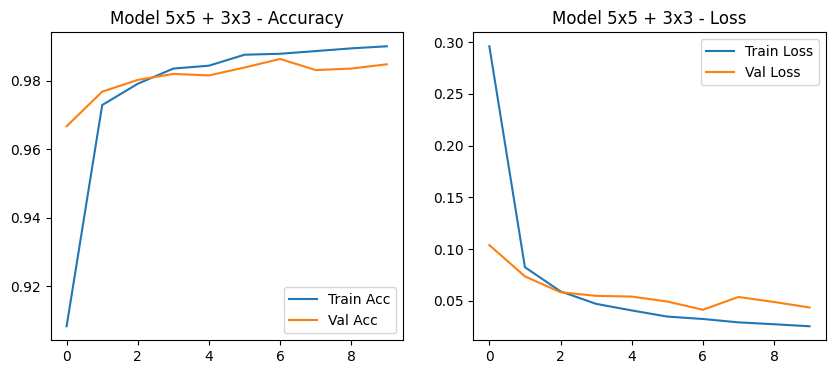

Точность Model 5x5 + 3x3: 0.9848


<Sequential name=sequential_3, built=True>

In [4]:
def build_and_train_model(name, model):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    hist = model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=1)
    results_log[name] = acc
    plot_history(hist, name)
    print(f"Точность {name}: {acc:.4f}")
    return model

# 2.1 Фильтры 7x7
model_7x7 = models.Sequential([
    layers.Conv2D(32, (7, 7), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (7, 7), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 7x7", model_7x7)

# 2.2 Фильтры 5x5
model_5x5 = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 5x5", model_5x5)

# 2.3 Фильтр 5x5 затем 3x3
model_5x5_3x3 = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 5x5 + 3x3", model_5x5_3x3)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,512 (2.54 MB)

 Trainable params: 666,512 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8983 - loss: 0.3177 - val_accuracy: 0.9621 - val_loss: 0.1224
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.9675 - loss: 0.0970 - val_accuracy: 0.9664 - val_loss: 0.0987
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9761 - loss: 0.0695 - val_accuracy: 0.9717 - val_loss: 0.0825
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.9796 - loss: 0.0562 - val_accuracy: 0.9766 - val_loss: 0.0696
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9829 - loss: 0.0476 - val_accuracy: 0.9790 - val_loss: 0.0630
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9846 - loss: 0.0416 - val_accuracy: 0.9813 - val_loss: 0.0571
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9856 - loss: 0.0399 - val_accuracy: 0.9807 - val_loss: 0.0569
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9866 -

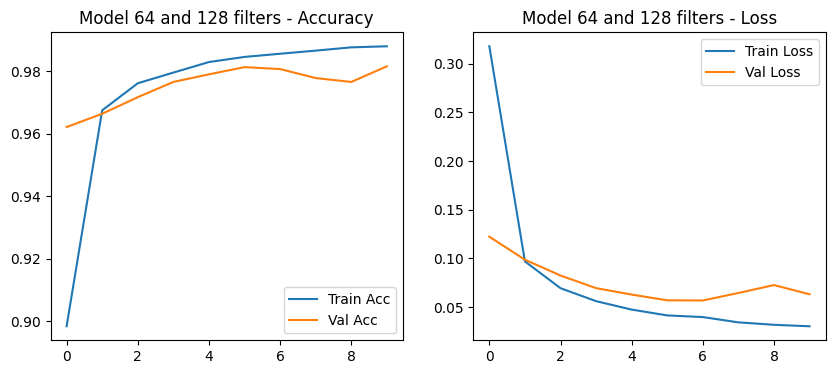

Точность Model 64 and 128 filters: 0.9816


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,168 (301.44 KB)

 Trainable params: 77,168 (301.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8367 - loss: 0.5298 - val_accuracy: 0.9282 - val_loss: 0.2332
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9456 - loss: 0.1709 - val_accuracy: 0.9544 - val_loss: 0.1471
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9622 - loss: 0.1140 - val_accuracy: 0.9572 - val_loss: 0.1316
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9696 - loss: 0.0881 - val_accuracy: 0.9704 - val_loss: 0.0877
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9745 - loss: 0.0722 - val_accuracy: 0.9714 - val_loss: 0.0853
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9778 - loss: 0.0616 - val_accuracy: 0.9759 - val_loss: 0.0723
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9797 - loss: 0.0546 - val_accuracy: 0.9712 - val_loss: 0.0763
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9817 - loss: 0.0494 - 

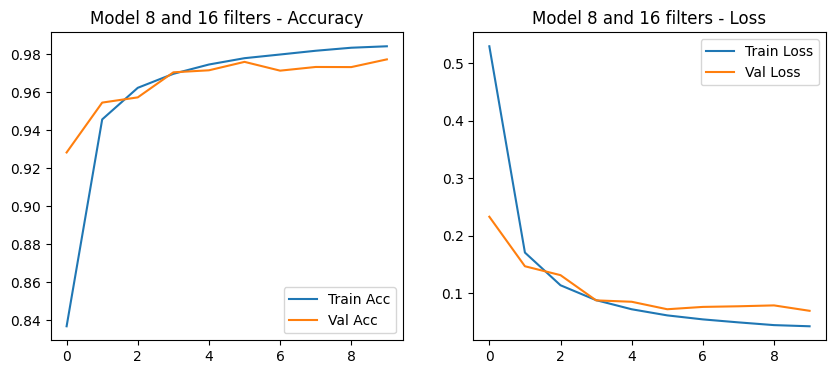

Точность Model 8 and 16 filters: 0.9772


<Sequential name=sequential_5, built=True>

In [5]:
# 3.1 Фильтры 64 и 128
model_64_128 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 64 and 128 filters", model_64_128)

# 3.2 Фильтры 8 и 16
model_8_16 = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 8 and 16 filters", model_8_16)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,472 (2.26 MB)

 Trainable params: 591,472 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9202 - loss: 0.2473 - val_accuracy: 0.9757 - val_loss: 0.0754
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9790 - loss: 0.0628 - val_accuracy: 0.9758 - val_loss: 0.0633
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.9833 - loss: 0.0465 - val_accuracy: 0.9816 - val_loss: 0.0527
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9861 - loss: 0.0390 - val_accuracy: 0.9847 - val_loss: 0.0409
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9878 - loss: 0.0341 - val_accuracy: 0.9892 - val_loss: 0.0346
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9887 - loss: 0.0296 - val_accuracy: 0.9861 - val_loss: 0.0428
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9895 - loss: 0.0270 - val_accuracy: 0.9826 - val_loss: 0.0512
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9897 -

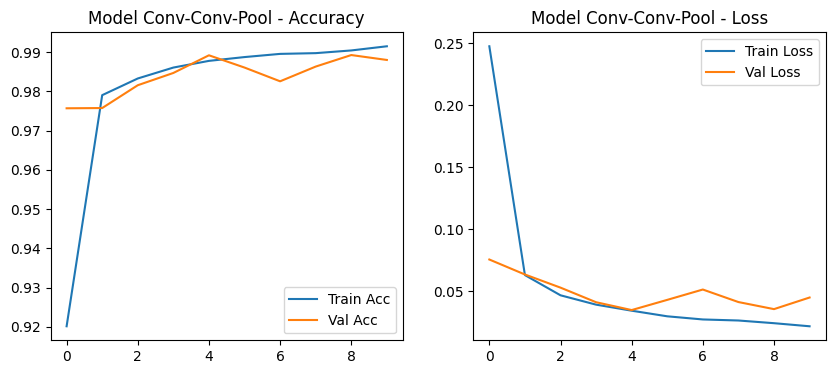

Точность Model Conv-Conv-Pool: 0.9880


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 15, 15, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,464 (829.94 KB)

 Trainable params: 212,464 (829.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8726 - loss: 0.4158 - val_accuracy: 0.9256 - val_loss: 0.2204
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9586 - loss: 0.1286 - val_accuracy: 0.9595 - val_loss: 0.1193
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9717 - loss: 0.0854 - val_accuracy: 0.9664 - val_loss: 0.0974
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9765 - loss: 0.0682 - val_accuracy: 0.9679 - val_loss: 0.0924
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9807 - loss: 0.0547 - val_accuracy: 0.9774 - val_loss: 0.0700
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9827 - loss: 0.0484 - val_accuracy: 0.9764 - val_loss: 0.0671
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9843 - loss: 0.0428 - val_accuracy: 0.9803 - val_loss: 0.0575
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9852 - loss: 0.0397 - 

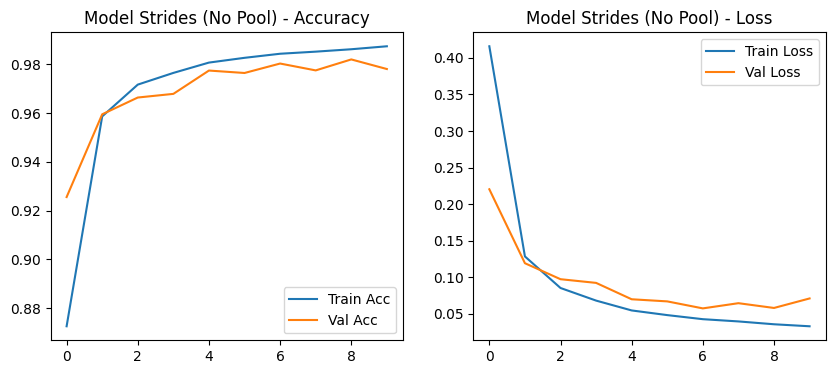

Точность Model Strides (No Pool): 0.9781


<Sequential name=sequential_7, built=True>

In [6]:
# 4.1 Чередование (Conv-Conv-Pool)
model_alt_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model Conv-Conv-Pool", model_alt_1)

# 4.2 Свертки с шагом stride=2 вместо MaxPooling
model_alt_2 = models.Sequential([
    layers.Conv2D(32, (3, 3), strides=2, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), strides=2, activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model Strides (No Pool)", model_alt_2)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,296 (630.06 KB)

 Trainable params: 160,848 (628.31 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.8606 - loss: 0.4492 - val_accuracy: 0.9476 - val_loss: 0.1622
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9438 - loss: 0.1775 - val_accuracy: 0.9660 - val_loss: 0.1012
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9560 - loss: 0.1334 - val_accuracy: 0.4977 - val_loss: 3.2623
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9628 - loss: 0.1113 - val_accuracy: 0.2971 - val_loss: 7.3389
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9680 - loss: 0.0943 - val_accuracy: 0.8989 - val_loss: 0.3318
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9717 - loss: 0.0841 - val_accuracy: 0.9696 - val_loss: 0.0957
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9752 - loss: 0.0716 - val_accuracy: 0.8412 - val_loss: 0.8558
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9768 -

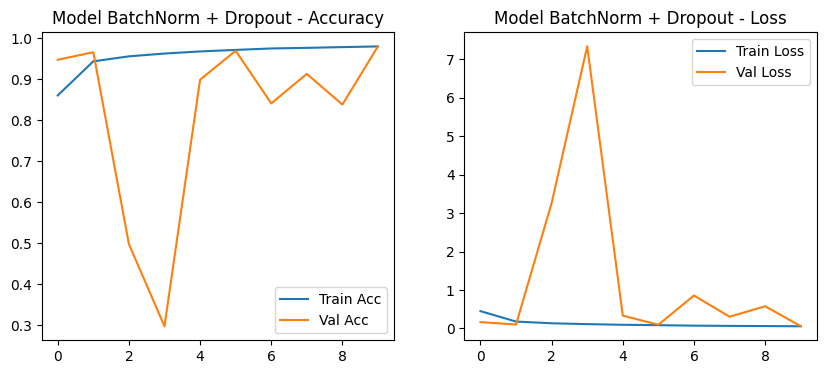

Точность Model BatchNorm + Dropout: 0.9806


In [7]:
# 5. Батч-нормализация и Dropout
model_bn_drop = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(NUM_CLASSES, activation='softmax')
])
best_model_candidate = build_and_train_model("Model BatchNorm + Dropout", model_bn_drop)

In [38]:
# --- Итоговое сравнение всех моделей ---

# Проверка: если по какой-то причине results_log не определен, создаем пустой
if 'results_log' not in locals():
    print("Внимание: results_log не был найден. Убедитесь, что запускали предыдущие ячейки.")
    results_log = {}

print("\n--- Итоговое сравнение моделей ---")
if not results_log:
    print("Лог результатов пуст. Нечего сравнивать.")
else:
    # 1. Сортировка и вывод всех результатов
    sorted_results = sorted(results_log.items(), key=lambda item: item[1], reverse=True)
    
    for name, acc in sorted_results:
        print(f"{name:25} | Точность: {acc:.4f}")

    # 2. Автоматический выбор лучшей модели по названию
    best_model_name = sorted_results[0][0]
    print(f"\n Лучшая модель по метрике Accuracy: {best_model_name}")

    # 3. Сопоставление названия с объектом модели
    model_map = {
        "Base Model": base_model,
        "Model 7x7": model_7x7,
        "Model 5x5": model_5x5,
        "Model 5x5 + 3x3": model_5x5_3x3,
        "Model 64 and 128 filters": model_64_128,
        "Model 8 and 16 filters": model_8_16,
        "Model Conv-Conv-Pool": model_alt_1,
        "Model Strides (No Pool)": model_alt_2,
        "Model BatchNorm + Dropout": model_bn_drop
    }

    best_model_obj = model_map.get(best_model_name)

    if best_model_obj:
        # 4. Сохранение
        save_name = 'best_cnn_model.h5'
        best_model_obj.save(save_name)
        print(f" Модель '{best_model_name}' сохранена как '{save_name}'")


--- Итоговое сравнение моделей ---
Model Conv-Conv-Pool      | Точность: 0.9880
Model 5x5                 | Точность: 0.9858
Model 7x7                 | Точность: 0.9850
Model 5x5 + 3x3           | Точность: 0.9848
Model 64 and 128 filters  | Точность: 0.9816
Base Model                | Точность: 0.9809
Model BatchNorm + Dropout | Точность: 0.9806
Model Strides (No Pool)   | Точность: 0.9781
Model 8 and 16 filters    | Точность: 0.9772

 Лучшая модель по метрике Accuracy: Model Conv-Conv-Pool
 Модель 'Model Conv-Conv-Pool' сохранена как 'best_cnn_model.h5'



 Результат 'model_alt_1' (Gamma: 0.35):
   → Предсказано: 5 (100.0%)


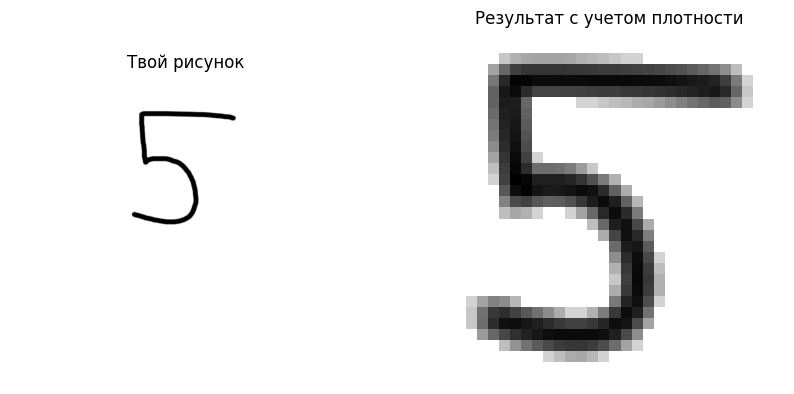

In [17]:
from tensorflow.keras.models import load_model

def preprocess_for_inference(image_path, img_size=32, invert=False, gamma=1.0):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Не удалось прочитать: {image_path}")
    
    original = img.copy()
    
    if invert:
        img = cv2.bitwise_not(img)
    
    # 1. Центрирование и кроп
    mask = cv2.bitwise_not(img) 
    coords = cv2.findNonZero(mask)
    
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        padding = int(max(w, h) * 0.15)
        x_start, y_start = max(0, x - padding), max(0, y - padding)
        x_end = min(img.shape[1], x + w + padding)
        y_end = min(img.shape[0], y + h + padding)
        img = img[y_start:y_end, x_start:x_end]

    # 2. Делаем квадратный белый фон
    h, w = img.shape[:2]
    side = max(h, w)
    square = np.full((side, side), 255, dtype=np.uint8) 
    ax, ay = (side - w) // 2, (side - h) // 2
    square[ay:ay+h, ax:ax+w] = img
    
    # 3. Ресайз
    img_resized = cv2.resize(square, (img_size, img_size), interpolation=cv2.INTER_AREA)
    
    # 4. Легкое размытие
    img_resized = cv2.GaussianBlur(img_resized, (3, 3), 0)
    
    # Инвертируем, чтобы гамма работала именно на цифру, а не на фон
    img_inv = cv2.bitwise_not(img_resized)
    img_float = img_inv.astype(np.float32) / 255.0
    img_corrected = np.power(img_float, gamma) # Применяем плотность
    
    img_final = cv2.bitwise_not((img_corrected * 255).astype(np.uint8))
    img_normalized = img_final.astype(np.float32) / 255.0
    
    
    img_input = img_normalized.reshape(1, img_size, img_size, 1)
    
    return original, img_final, img_input

def predict_custom_image(image_path, model_name='model_alt_1', invert=True, gamma=1.0): 
    model_path = f'saved_models/{model_name}.h5'
    
    if not os.path.exists(model_path):
        if os.path.exists(f'{model_name}.h5'):
            model_path = f'{model_name}.h5'
        else:
            print(f"❌ Модель {model_name} не найдена!")
            return
    
    model = load_model(model_path)
    
    try:
        # Передаем gamma в функцию предобработки
        original_img, processed_img, img_input = preprocess_for_inference(image_path, invert=invert, gamma=gamma)
    except Exception as e:
        print(f"Ошибка: {e}")
        return
    
    preds = model.predict(img_input, verbose=0)
    class_idx = np.argmax(preds)
    confidence = np.max(preds) * 100
    
    print(f"\n Результат '{model_name}' (Gamma: {gamma}):")
    print(f"   → Предсказано: {class_names[class_idx]} ({confidence:.1f}%)")
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Твой рисунок")
    axes[0].axis('off')
    
    axes[1].imshow(processed_img, cmap='gray')
    axes[1].set_title("Результат с учетом плотности")
    axes[1].axis('off')
    
    plt.show()

# Запуск
YOUR_IMAGE_NAME = 'five.png' 
CHOSEN_MODEL = 'model_alt_1' 

if os.path.exists(YOUR_IMAGE_NAME):
    
    predict_custom_image(YOUR_IMAGE_NAME, model_name=CHOSEN_MODEL, invert=False, gamma=0.35) 
else:
    print(f"Файл {YOUR_IMAGE_NAME} не найден")

500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


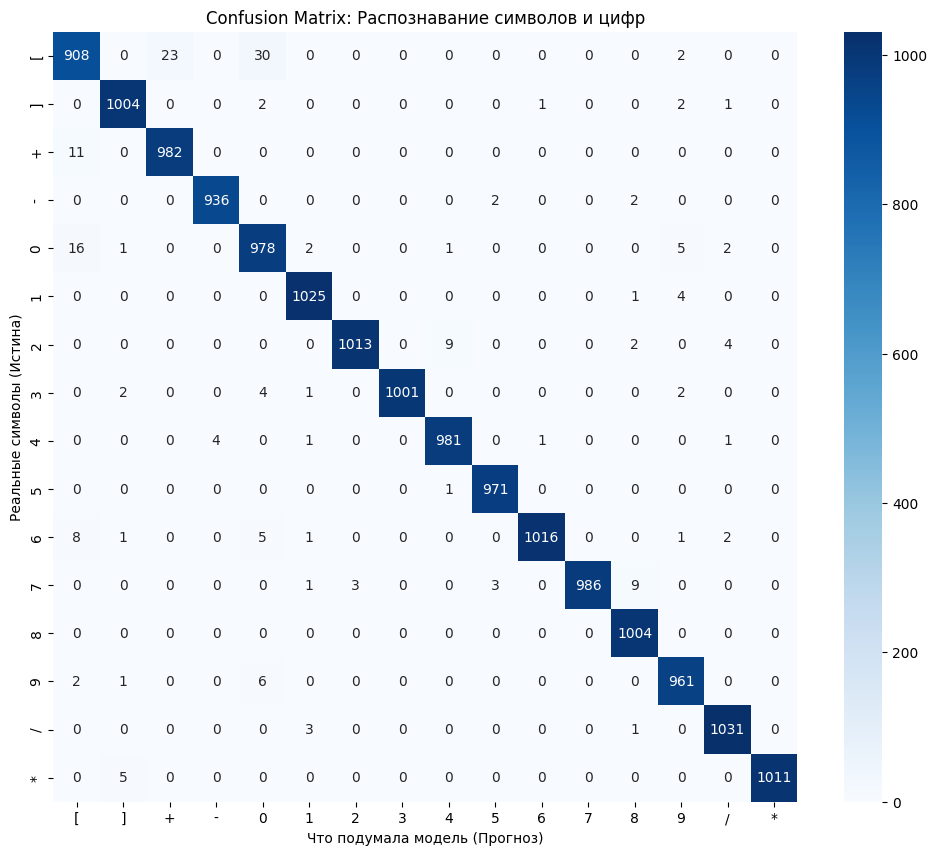

In [56]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Получаем предсказания модели на тестовой выборке
y_pred_probs = best_model_obj.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 2. Список имен классов 
my_class_names = ['[', ']', '+', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '/', '*']

# 3. Создаем матрицу ошибок
cm = confusion_matrix(y_true, y_pred_classes)

# 4. Визуализация через Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=my_class_names, 
            yticklabels=my_class_names)

plt.title('Confusion Matrix: Распознавание символов и цифр')
plt.ylabel('Реальные символы (Истина)')
plt.xlabel('Что подумала модель (Прогноз)')
plt.show()